# H2 — Procedural Level Generation via Wave Function Collapse + CP-SAT

Three approaches compared:
- **Random**: no constraints, pure weighted sampling
- **WFC (pure)**: AC-3 propagation + backtracking (classic algorithm)
- **CP-SAT**: OR-Tools constraint model with global floor-ratio constraint

Run all cells top-to-bottom.

In [3]:
# Install dependencies if needed
# !pip install ortools matplotlib ipywidgets numpy
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import ipywidgets as widgets
from IPython.display import display, clear_output
import math, time, random

from wfc_cpsat import load_tileset, generate_random, PureWFC, solve_cpsat, run_all




#
 
 1. Tileset inspector
Shows the tile palette and adjacency rules.

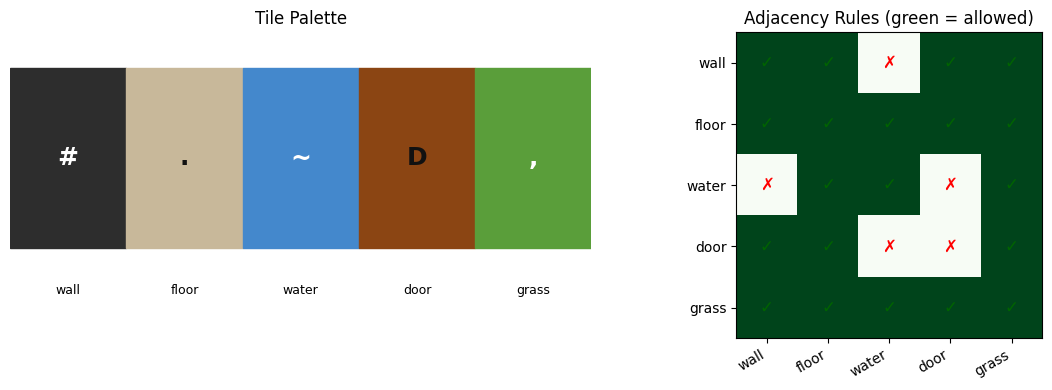

In [6]:
tileset = load_tileset()
tiles = tileset['tiles']
rules = {int(k): v for k, v in tileset['adjacency']['rules'].items()}
n = len(tiles)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Tile palette
ax = axes[0]
for i, t in enumerate(tiles):
    rect = plt.Rectangle((i, 0), 1, 1, color=t['color'])
    ax.add_patch(rect)
    ax.text(i + 0.5, 0.5, t['char'], ha='center', va='center', fontsize=18, fontweight='bold',
            color='white' if t['color'] < '#888888' else '#111')
    ax.text(i + 0.5, -0.2, t['name'], ha='center', va='top', fontsize=9)
ax.set_xlim(0, n)
ax.set_ylim(-0.5, 1.2)
ax.axis('off')
ax.set_title('Tile Palette')

# Adjacency matrix
ax2 = axes[1]
matrix = np.array([rules[i] for i in range(n)], dtype=float)
im = ax2.imshow(matrix, cmap='Greens', vmin=0, vmax=1)
ax2.set_xticks(range(n))
ax2.set_yticks(range(n))
ax2.set_xticklabels([t['name'] for t in tiles], rotation=30, ha='right')
ax2.set_yticklabels([t['name'] for t in tiles])
ax2.set_title('Adjacency Rules (green = allowed)')
for i in range(n):
    for j in range(n):
        ax2.text(j, i, '✓' if rules[i][j] else '✗', ha='center', va='center',
                 color='darkgreen' if rules[i][j] else 'red', fontsize=12)
plt.tight_layout()
plt.show()

## 2. WFC step-by-step animation
Watch domains collapse cell by cell. Use the slider to scrub through steps.

In [7]:
ROWS, COLS = 10, 10
SEED = 42

class WFCRecorder(PureWFC):
    """Same as PureWFC but records domain snapshots after each collapse."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.snapshots = []  # list of (domains_copy, collapsed_cell)
        self._record(None)

    def _record(self, cell):
        snap = [[set(self.domains[r][c]) for c in range(self.cols)] for r in range(self.rows)]
        self.snapshots.append((snap, cell))

    def solve(self):
        stack = []
        while True:
            cell = self._pick_cell()
            if cell is None:
                grid = np.zeros((self.rows, self.cols), dtype=int)
                for r in range(self.rows):
                    for c in range(self.cols):
                        grid[r][c] = next(iter(self.domains[r][c]))
                self._record(None)
                return grid
            r, c = cell
            d = list(self.domains[r][c])
            w = [self.weights[t] for t in d]
            chosen = self.rng.choices(d, weights=w)[0]
            snap = [[set(self.domains[r2][c2]) for c2 in range(self.cols)] for r2 in range(self.rows)]
            stack.append((snap, r, c, chosen))
            self.domains[r][c] = {chosen}
            ok = self._propagate(r, c)
            self._record((r, c))
            while not ok:
                self.backtracks += 1
                if not stack:
                    return None
                snap, br, bc, bad_tile = stack.pop()
                self.domains = [[set(snap[r2][c2]) for c2 in range(self.cols)] for r2 in range(self.rows)]
                self.domains[br][bc].discard(bad_tile)
                if not self.domains[br][bc]:
                    continue
                ok = self._propagate(br, bc)
                self._record((br, bc))

recorder = WFCRecorder(ROWS, COLS, tileset, SEED)
final_grid = recorder.solve()
print(f"Steps: {len(recorder.snapshots)}  |  Backtracks: {recorder.backtracks}")

Steps: 102  |  Backtracks: 0


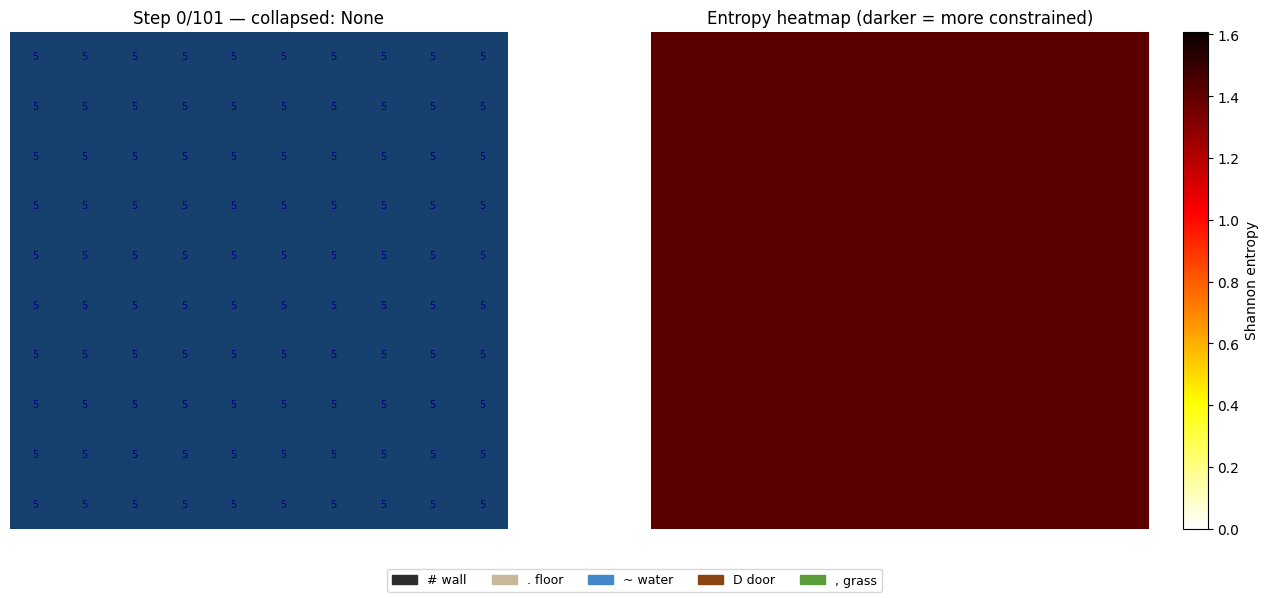

In [8]:
tile_colors = [t['color'] for t in tiles]
cmap = mcolors.ListedColormap(tile_colors)
bounds = list(range(len(tiles) + 1))
norm = mcolors.BoundaryNorm(bounds, cmap.N)

def render_step(step_idx):
    snap, collapsed_cell = recorder.snapshots[step_idx]
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: entropy heatmap
    entropy_grid = np.zeros((ROWS, COLS))
    tile_img = np.full((ROWS, COLS), -1, dtype=float)
    for r in range(ROWS):
        for c in range(COLS):
            d = snap[r][c]
            if len(d) == 1:
                tile_img[r][c] = next(iter(d))
                entropy_grid[r][c] = 0
            elif len(d) == 0:
                entropy_grid[r][c] = -1
            else:
                w = [tileset['weights'][t] for t in d]
                s = sum(w)
                entropy_grid[r][c] = -sum((wi/s)*math.log(wi/s) for wi in w if wi > 0)

    ax = axes[0]
    collapsed_mask = tile_img >= 0
    display_img = np.where(collapsed_mask, tile_img, 0)
    im = ax.imshow(display_img, cmap=cmap, norm=norm, interpolation='nearest')
    # overlay uncollapsed cells with entropy shade
    ent_overlay = np.ma.masked_where(collapsed_mask, entropy_grid)
    ax.imshow(ent_overlay, cmap='Blues', alpha=0.6, interpolation='nearest',
              vmin=0, vmax=math.log(len(tiles)))
    if collapsed_cell:
        ax.add_patch(plt.Rectangle((collapsed_cell[1]-0.5, collapsed_cell[0]-0.5), 1, 1,
                                    fill=False, edgecolor='red', linewidth=3))
    # tile chars
    for r in range(ROWS):
        for c in range(COLS):
            d = snap[r][c]
            if len(d) == 1:
                t = next(iter(d))
                ax.text(c, r, tiles[t]['char'], ha='center', va='center', fontsize=9,
                        color='white' if tiles[t]['color'] < '#888888' else '#111')
            elif len(d) > 1:
                ax.text(c, r, str(len(d)), ha='center', va='center', fontsize=7, color='navy')
    ax.set_title(f'Step {step_idx}/{len(recorder.snapshots)-1} — collapsed: {collapsed_cell}')
    ax.axis('off')

    # Right: entropy heatmap only
    ax2 = axes[1]
    im2 = ax2.imshow(entropy_grid, cmap='hot_r', interpolation='nearest',
                     vmin=0, vmax=math.log(len(tiles)))
    plt.colorbar(im2, ax=ax2, label='Shannon entropy')
    ax2.set_title('Entropy heatmap (darker = more constrained)')
    ax2.axis('off')

    legend = [mpatches.Patch(color=t['color'], label=f"{t['char']} {t['name']}") for t in tiles]
    fig.legend(handles=legend, loc='lower center', ncol=len(tiles), fontsize=9)
    plt.tight_layout(rect=[0, 0.07, 1, 1])
    plt.show()

slider = widgets.IntSlider(min=0, max=len(recorder.snapshots)-1, value=0,
                           description='Step:', continuous_update=False, layout=widgets.Layout(width='80%'))
out = widgets.Output()

def on_change(change):
    with out:
        clear_output(wait=True)
        render_step(change['new'])

slider.observe(on_change, names='value')
display(widgets.VBox([slider, out]))
render_step(0)

## 3. Side-by-side comparison: Random vs WFC vs CP-SAT

In [9]:
GRID_SIZE = 12
print(f"Running all three methods on {GRID_SIZE}x{GRID_SIZE} grid...")
results, tileset = run_all(rows=GRID_SIZE, cols=GRID_SIZE, seed=SEED)
for name, r in results.items():
    bt = f", backtracks={r['backtracks']}" if r['backtracks'] else ''
    print(f"  {name:8s}: {r['time']:.3f}s  status={r['status']}{bt}")

Running all three methods on 12x12 grid...
  random  : 0.001s  status=done
  wfc     : 0.042s  status=done
  cpsat   : 0.032s  status=OPTIMAL


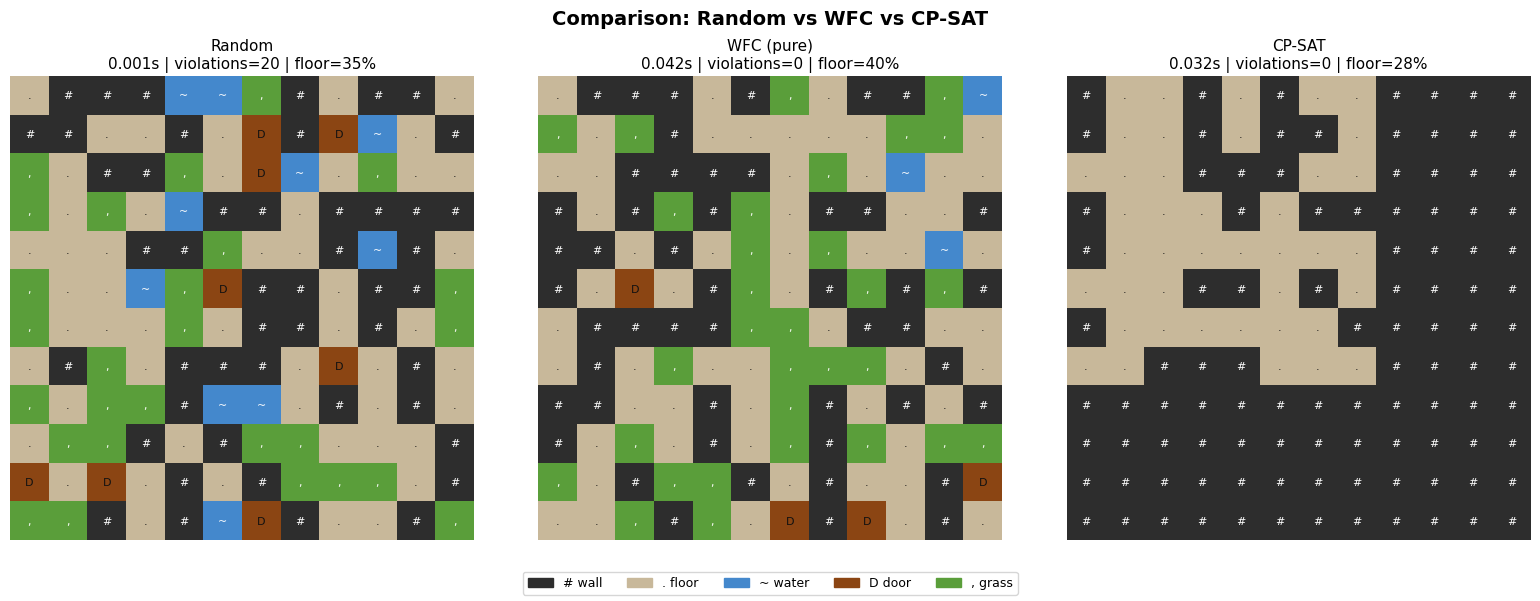

In [10]:
def plot_grid(ax, grid, title, tileset):
    tiles = tileset['tiles']
    cmap_l = mcolors.ListedColormap([t['color'] for t in tiles])
    bounds_l = list(range(len(tiles) + 1))
    norm_l = mcolors.BoundaryNorm(bounds_l, cmap_l.N)
    ax.imshow(grid, cmap=cmap_l, norm=norm_l, interpolation='nearest')
    for r in range(grid.shape[0]):
        for c in range(grid.shape[1]):
            t = grid[r, c]
            ax.text(c, r, tiles[t]['char'], ha='center', va='center', fontsize=8,
                    color='white' if tiles[t]['color'] < '#888888' else '#111')
    ax.set_title(title, fontsize=11)
    ax.axis('off')

def adjacency_violations(grid, rules):
    rows, cols = grid.shape
    v = 0
    for r in range(rows):
        for c in range(cols):
            for nr, nc in [(r, c+1), (r+1, c)]:
                if nr < rows and nc < cols:
                    if not rules[grid[r, c]][grid[nr, nc]]:
                        v += 1
    return v

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
labels = {
    'random': 'Random',
    'wfc': 'WFC (pure)',
    'cpsat': 'CP-SAT'
}
for ax, (name, r) in zip(axes, results.items()):
    grid = r['grid']
    if grid is None:
        ax.text(0.5, 0.5, f'{name}\nFAILED\n({r["status"]})', ha='center', va='center',
                transform=ax.transAxes, fontsize=14, color='red')
        ax.axis('off')
        continue
    viol = adjacency_violations(grid, rules)
    floor_pct = (grid == 1).sum() / grid.size * 100
    t = r['time']
    title = f"{labels[name]}\n{t:.3f}s | violations={viol} | floor={floor_pct:.0f}%"
    plot_grid(ax, grid, title, tileset)

legend = [mpatches.Patch(color=t['color'], label=f"{t['char']} {t['name']}") for t in tileset['tiles']]
fig.legend(handles=legend, loc='lower center', ncol=len(tileset['tiles']), fontsize=9)
plt.suptitle('Comparison: Random vs WFC vs CP-SAT', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.show()

## 4. Metrics bar chart

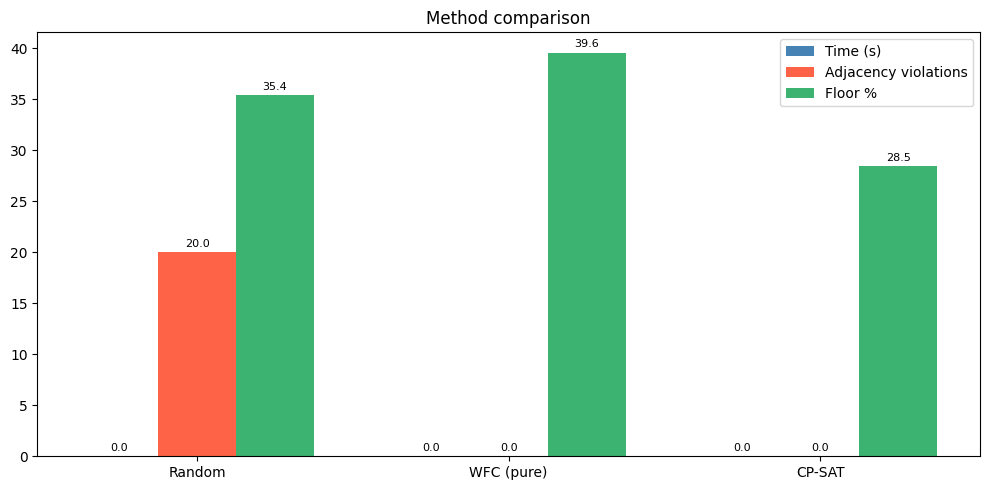

In [11]:
import matplotlib.pyplot as plt
import numpy as np

methods = list(results.keys())
times   = [results[m]['time'] for m in methods]
viols   = [adjacency_violations(results[m]['grid'], rules) if results[m]['grid'] is not None else 0 for m in methods]
floors  = [(results[m]['grid'] == 1).sum() / results[m]['grid'].size * 100
           if results[m]['grid'] is not None else 0 for m in methods]

x = np.arange(len(methods))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w, times,  w, label='Time (s)',             color='steelblue')
bars2 = ax.bar(x,     viols,  w, label='Adjacency violations', color='tomato')
bars3 = ax.bar(x + w, floors, w, label='Floor % ',             color='mediumseagreen')

for bars in [bars1, bars2, bars3]:
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                f'{b.get_height():.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([labels[m] for m in methods])
ax.set_title('Method comparison')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Interactive generator
Change seed and grid size, regenerate on the fly.

In [ ]:
seed_w  = widgets.IntSlider(min=0, max=200, value=42,  description='Seed:')
size_w  = widgets.IntSlider(min=5,  max=20,  value=12, description='Grid size:')
floor_w = widgets.FloatSlider(min=0.1, max=0.8, value=0.25, step=0.05, description='Min floor:')
btn     = widgets.Button(description='Generate', button_style='success')
out2    = widgets.Output()

def generate(_):
    with out2:
        clear_output(wait=True)
        s, sz, mf = seed_w.value, size_w.value, floor_w.value
        print(f"Generating {sz}x{sz}, seed={s}, min_floor={mf:.0%}...")
        res, ts = run_all(sz, sz, s)
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for ax, (name, r) in zip(axes, res.items()):
            if r['grid'] is None:
                ax.text(0.5, 0.5, 'FAILED', ha='center', va='center',
                        transform=ax.transAxes, fontsize=14, color='red')
                ax.axis('off')
                continue
            viol = adjacency_violations(r['grid'], rules)
            plot_grid(ax, r['grid'],
                      f"{labels[name]}\n{r['time']:.3f}s | viol={viol}", ts)
        plt.tight_layout()
        plt.show()

btn.on_click(generate)
display(widgets.HBox([seed_w, size_w, floor_w, btn]), out2)

Output()